In [1]:
import pandas as pd

In [5]:
df = pd.read_csv("../data/processed/concatenated_title_selftext.csv")
df.head()

,id,text,subreddit
0,1j3g0q5,Trudeau - ''I want to speak first directly to ...,popculture
1,1jdfbt3,Kim Kardashian endorses Nazi Elon Musk’s cyber...,popculture
2,1k7jcux,Candace Owens saying she no longer supports Do...,popculture
3,1ilwij6,Kendrick Lamar called out for no white perform...,popculture
4,1jfzx63,"Elon Musk's daughter, Vivian Wilson, stars in ...",popculture


In [ ]:
df = pd.read_csv("../data/processed/preprocess_text.csv")
df.head()

,id,text,text_clean
0,1j3g0q5,Trudeau - ''I want to speak first directly to ...,trudeau want speak first directly american peo...
1,1jdfbt3,Kim Kardashian endorses Nazi Elon Musk’s cyber...,kardashian endorses nazi elon musk cybertruck ...
2,1k7jcux,Candace Owens saying she no longer supports Do...,candace owen long support donald trump
3,1ilwij6,Kendrick Lamar called out for no white perform...,kendrick lamar call white performer super bowl...
4,1jfzx63,"Elon Musk's daughter, Vivian Wilson, stars in ...",elon musk daughter vivian wilson star first ev...


In [2]:
df = pd.read_parquet("../data/processed/subreddit_centroids.parquet")
df.head()

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
subreddit,,,,,,,,,,,,,,,,,,,,,
07nsfw,0.057697,0.048046,0.102488,-0.090343,0.007014,-0.012705,0.287642,0.093900,-0.073208,0.015777,...,0.119064,-0.110381,-0.114244,0.082854,-0.191469,0.156884,0.223848,-0.067966,0.002179,-0.074987
0sanitymemes,0.019638,0.040786,-0.007463,0.024511,-0.045179,-0.063480,0.217152,0.074525,0.027779,-0.005328,...,0.073487,-0.078881,0.030652,0.039997,-0.184628,0.092009,0.207246,-0.065628,0.035413,0.044643
0xpolygon,-0.013941,-0.143177,0.016114,-0.150407,-0.078615,-0.079147,-0.053098,0.140395,-0.050836,0.041453,...,0.148797,-0.174917,-0.111648,0.053259,0.018578,0.082971,0.016512,-0.061432,-0.070326,0.052382
100gecs,-0.046298,0.039677,0.039849,0.009093,-0.015335,-0.052222,0.308050,0.069182,0.023236,0.053200,...,0.139292,-0.116448,-0.025767,0.015651,-0.177113,0.064958,0.145968,-0.055374,-0.070252,0.056906
100kanojo,-0.086924,-0.014663,0.005690,0.048817,-0.029729,0.020171,0.177156,0.012908,0.060865,0.056836,...,0.058768,-0.055148,0.036123,0.010994,-0.061919,0.142867,0.304874,-0.018741,-0.082211,0.006724


Carregando centroides...
Reduzindo dimensões com UMAP...


/home/mateus/reddit/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Executando HDBSCAN...
Número de clusters detectados: 39


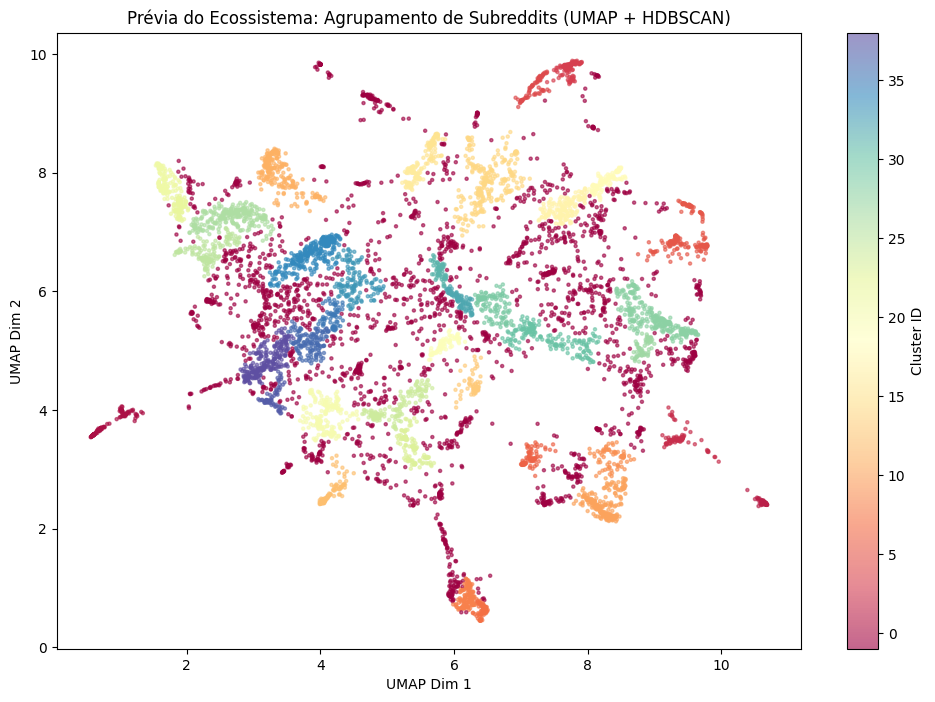

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import hdbscan

# 1. Carregar os centroides
print("Carregando centroides...")
df_centroids = pd.read_parquet("../data/processed/subreddit_centroids.parquet")
matrix = df_centroids.values

# 2. Redução de Dimensionalidade com UMAP
# Reduzimos de 384d para 2d para visualização
print("Reduzindo dimensões com UMAP...")
reducer = umap.UMAP(
    n_neighbors=50,       # Aumentado de 15 para 50
    min_dist=0.0,         # Reduzido de 0.1 para 0.0
    n_components=2, 
    metric='cosine', 
    random_state=42
)
embedding_2d = reducer.fit_transform(matrix)

# 3. Clusterização com HDBSCAN
print("Executando HDBSCAN...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=60,     # Aumentado para gerar clusters maiores e menos tópicos
    min_samples=1,           # REDUZIR este valor resgata os outliers (menos conservador)
    metric='euclidean', 
    cluster_selection_method='leaf' # 'leaf' tende a agrupar mais que o 'eom' em alguns casos
)
clusterer.fit(embedding_2d)
cluster_labels = clusterer.labels_

# 4. Plotagem
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    embedding_2d[:, 0], 
    embedding_2d[:, 1], 
    c=cluster_labels, 
    cmap='Spectral', 
    s=5, 
    alpha=0.6
)

plt.colorbar(scatter, label='Cluster ID')
plt.title('Prévia do Ecossistema: Agrupamento de Subreddits (UMAP + HDBSCAN)')
plt.xlabel('UMAP Dim 1')
plt.ylabel('UMAP Dim 2')

# Identificar ruído (pontos que o HDBSCAN não conseguiu agrupar são label -1)
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
print(f"Número de clusters detectados: {n_clusters}")

plt.show()

In [9]:
# Criar o DataFrame de resultados vinculando o nome do subreddit ao seu cluster
df_results = pd.DataFrame({
    'subreddit': df_centroids.index,
    'cluster': cluster_labels,
    'umap_1': embedding_2d[:, 0],
    'umap_2': embedding_2d[:, 1]
})

# 5. Analisar o tamanho dos clusters
counts = df_results['cluster'].value_counts().sort_index()
print("\nContagem de subreddits por cluster:")
print(counts)


Contagem de subreddits por cluster:
cluster
-1     2281
 0      155
 1       89
 2       91
 3      141
 4       73
 5      188
 6       80
 7       80
 8      124
 9       74
 10     239
 11     224
 12     111
 13      61
 14     252
 15      78
 16      82
 17     151
 18     107
 19      67
 20     171
 21     109
 22      75
 23     108
 24     137
 25     130
 26     243
 27      60
 28     260
 29     110
 30     168
 31      61
 32      87
 33     136
 34     274
 35      66
 36     133
 37      63
 38     233
Name: count, dtype: int64


In [10]:
# 1. Calcular contagens e porcentagens
counts = df_results['cluster'].value_counts()
percent = df_results['cluster'].value_counts(normalize=True) * 100

# 2. Criar um DataFrame de resumo
df_summary = pd.DataFrame({
    'Qtd_Subreddits': counts,
    'Porcentagem (%)': percent.round(2)
})

# Opcional: Remover o ruído (-1) da visualização principal para focar nos grupos reais
# df_summary = df_summary.drop(-1, errors='ignore')

print(df_summary)

         Qtd_Subreddits  Porcentagem (%)
cluster                                 
-1                 2281            30.94
 34                 274             3.72
 28                 260             3.53
 14                 252             3.42
 26                 243             3.30
 10                 239             3.24
 38                 233             3.16
 11                 224             3.04
 5                  188             2.55
 20                 171             2.32
 30                 168             2.28
 0                  155             2.10
 17                 151             2.05
 3                  141             1.91
 24                 137             1.86
 33                 136             1.84
 36                 133             1.80
 25                 130             1.76
 8                  124             1.68
 12                 111             1.51
 29                 110             1.49
 21                 109             1.48
 23             

In [23]:
df_results[df_results['cluster'] == 0].head(100)

,subreddit,cluster,umap_1,umap_2
63,49ers,0,0.603983,3.576713
193,afl,0,0.764628,3.717143
303,anaheimducks,0,0.687898,3.654777
459,armwrestling,0,0.812352,3.764125
745,baseball,0,0.613200,3.586011
...,...,...,...,...
4517,nbaspurs,0,0.711082,3.685589
4518,nbatalk,0,0.652320,3.635044
4577,newyorkmets,0,0.590220,3.564532
4581,nfceastmemewar,0,0.615214,3.586127


In [24]:
df_results[df_results['subreddit'] == 'bdsmcommunity']

,subreddit,cluster,umap_1,umap_2
786,bdsmcommunity,28,9.116632,5.485757


In [25]:
df_results[df_results['subreddit'] == 'redpillwomen']

,subreddit,cluster,umap_1,umap_2
5453,redpillwomen,28,8.95633,5.635896


In [26]:
df_results[df_results['subreddit'] == 'mensrights']

,subreddit,cluster,umap_1,umap_2
4180,mensrights,28,8.433282,6.044587
